[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/LevantamentoLidarIME/blob/main/01_Intro.ipynb)

# Introdução ao LiDAR e às nuvens de pontos 3D

**Maj Diego / 2º semestre de 2026**

**Objetivos**

1. explicar como um LiDAR estima distância e suas aplicações;
2. interpretar coordenadas, intensidade, retornos, cor e classificação;
3. reconhecer os formatos PCD, LAS/LAZ, E57 e PLY;
4. explicar o que é SLAM;
5. explicar o sensor SLAM 100 e o produto.

## 1. O que é LiDAR?

**LiDAR** (*Light Detection and Ranging*) é uma técnica ativa de sensoriamento: o instrumento emite luz laser, detecta a energia que retorna e estima a distância até uma superfície. Em um sistema de tempo de voo, a relação idealizada é

$$R = \frac{c\,\Delta t}{2}$$

em que $R$ é o alcance, $c$ é a velocidade da luz e $\Delta t$ é o intervalo entre emissão e recepção. A divisão por dois representa o percurso de ida e volta. Alguns sensores usam diferença de fase ou outras estratégias, mas o produto geométrico continua dependendo da combinação entre distância e direção do feixe.

Conhecidos a posição e a orientação do sensor, uma medição polar pode ser transformada em coordenadas cartesianas. Em uma convenção simples:

$$x=R\cos(\theta)\cos(\phi),\quad y=R\cos(\theta)\sin(\phi),\quad z=R\sin(\theta)$$

<center><img src="media/imgs/LidarPortatil.jpg"> </center>

<center><img src="media/imgs/LidarCarro.jpg"> </center>


<center><img src="media/imgs/LidarDrone.jpg"> </center>


#### Como o LiDAR "enxerga" o mundo

<center><img src="media/imgs/lidar-view-from-car.jpg"> </center>

### 2. Nuvem de pontos e seus atributos

Uma nuvem é um conjunto de retornos discretos (pontos). Cada ponto possui ao menos as coordenadas **X, Y, Z** e pode carregar: tempo GPS, intensidade, número do retorno, quantidade de retornos, ângulo de varredura, classe, cor RGB, identificação da linha/faixa e indicadores de qualidade.

#### 2.1 Tipos de arquivos de nuvem de pontos

| Formato | Uso típico | Observações | Softwares para manipulação |
|---|---|---|---|
| PCD | PCL, robótica e experimentos | Estrutura simples; pode ser ASCII ou binária | PCL, CloudCompare, Open3D, PDAL |
| LAS | Intercâmbio geoespacial LiDAR | Cabeçalho, pontos, atributos, VLR/EVLR | LAStools, PDAL, CloudCompare, QGIS, ArcGIS Pro, Global Mapper |
| LAZ | LAS comprimido sem perda | Menor armazenamento; requer codec compatível | LAStools, LASzip, PDAL, CloudCompare, QGIS, ArcGIS Pro |
| E57 | Varreduras 3D e intercâmbio | Pode armazenar poses e imagens | CloudCompare, Autodesk ReCap, FARO SCENE, Leica Cyclone, Trimble RealWorks |
| PLY | Geometria, cor e malhas | Útil para visualização e processamento 3D | MeshLab, CloudCompare, Blender, Open3D, PCL |

#### 2.2 Exemplo: `bunny.pcd` com [Open3D](https://www.open3d.org/)

In [18]:
bunny_pcd = "dados/amostras/bunny.pcd"

f = open(bunny_pcd, 'r')
# To get everything in the file, just use read()
for id, line in enumerate(f):
    print(line.strip())  # strip() removes the newline character at the end of each line
    if id >= 15:  # Limit to first 10 lines for display
        break

# .PCD v.5 - Point Cloud Data file format
VERSION .5
FIELDS x y z
SIZE 4 4 4
TYPE F F F
COUNT 1 1 1
WIDTH 397
HEIGHT 1
POINTS 397
DATA ascii
0.0054216 0.11349 0.040749
-0.0017447 0.11425 0.041273
-0.010661 0.11338 0.040916
0.026422 0.11499 0.032623
0.024545 0.12284 0.024255
0.034137 0.11316 0.02507


In [24]:
import open3d as o3d
import numpy as np

pcd = o3d.io.read_point_cloud(bunny_pcd)
xyz = np.asarray(pcd.points)
print("XYZ's:\n", xyz)

eixos = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.06, origin=[0,0,0])
o3d.visualization.draw_plotly([eixos,pcd], width=600, height=500)

XYZ's:
 [[ 0.0054216  0.11349    0.040749 ]
 [-0.0017447  0.11425    0.041273 ]
 [-0.010661   0.11338    0.040916 ]
 ...
 [-0.064992   0.17802   -0.054645 ]
 [-0.069935   0.17983   -0.051988 ]
 [-0.07793    0.17516   -0.0444   ]]


#### 2.3 Exemplo: `arquivo.las` com [laspy](https://laspy.readthedocs.io/en/latest/index.html) e [Matplotlib](https://matplotlib.org/)

O LAS armazena coordenadas escaladas e atributos em registros binários. `laspy` aplica automaticamente escala e *offset* ao expor `las.x`, `las.y` e `las.z`. Primeiro inspecionaremos cabeçalho, limites e dimensões; depois criaremos uma geometria Open3D.

In [31]:
import laspy
from pprint import pprint
import numpy as np

arquivo_las = "dados/amostras/arquivo.las"
las = laspy.read(arquivo_las)

print("Informações do arquivo LAS:")
pprint(las.header.__dict__)
print("\nQuantidade de pontos:", las.header.point_count)
for dim in las.point_format.dimension_names:
    data = las[dim]
    print(f"{dim:20} | Min: {np.min(data):>10} | Max: {np.max(data):>10}")

Informações do arquivo LAS:
{'_point_format': <PointFormat(3, 0 bytes of extra dims)>,
 '_version': Version(major=1, minor=2),
 '_vlrs': [],
 'are_points_compressed': False,
 'creation_date': None,
 'evlrs': None,
 'extra_header_bytes': b'',
 'extra_vlr_bytes': b'\x00\x00',
 'file_source_id': 0,
 'generating_software': 'TerraScan',
 'global_encoding': <laspy.header.GlobalEncoding object at 0x000001E1A25FD3D0>,
 'gps_time_offset': 0,
 'max_gps_time': 0.0,
 'maxs': array([6.3898255e+05, 8.5353543e+05, 5.8638000e+02]),
 'min_gps_time': 0.0,
 'mins': array([6.3561985e+05, 8.4889970e+05, 4.0659000e+02]),
 'number_of_evlrs': 0,
 'number_of_points_by_return': array([925, 114,  21,   5,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0], dtype=uint64),
 'offset_to_point_data': 229,
 'offsets': array([-0., -0., -0.]),
 'point_count': 1065,
 'scales': array([0.01, 0.01, 0.01]),
 'start_of_first_evlr': 0,
 'start_of_waveform_data_packet_record': 0,
 'system_identifier': '',
 'uuid': UU

In [49]:
import geopandas as gpd
import matplotlib.pyplot as plt

las = laspy.read("dados/amostras/arquivo.las")

gdf = gpd.GeoDataFrame(
    {   "R": np.asarray(las.red),
        "G": np.asarray(las.green),
        "B": np.asarray(las.blue),
        "Z": np.asarray(las.z),
        "Intensidade": np.asarray(las.intensity),
        "Classificacao": np.asarray(las.classification),
    },
    geometry=gpd.points_from_xy(las.x, las.y),
    crs=las.header.parse_crs(),
)

display(gdf.head())

,R,G,B,Z,Intensidade,Classificacao,geometry
0,68,77,88,431.66,143,1,POINT (637012.24 849028.31)
1,54,66,68,446.39,18,1,POINT (636896.33 849087.7)
2,112,97,114,426.71,118,1,POINT (636784.74 849106.66)
3,178,138,162,425.39,100,1,POINT (636699.38 848991.01)
4,134,104,134,425.10,124,1,POINT (636601.87 849018.6)


<Axes: >

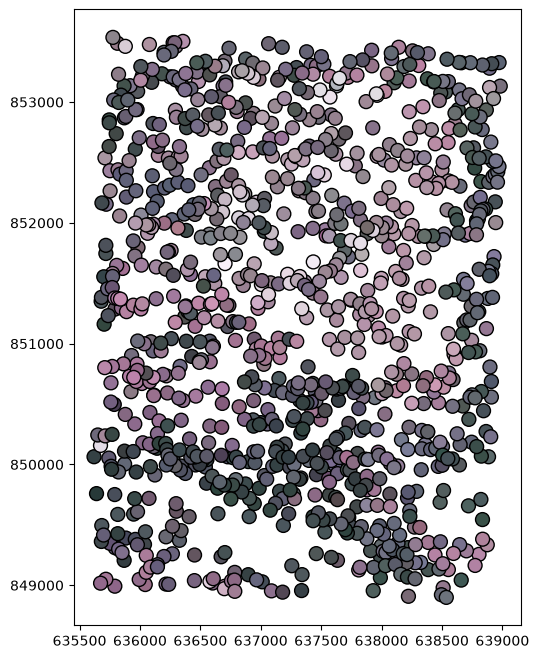

In [48]:
#  Convert RGB 0–255 to Matplotlib 0–1 scale
gdf['color'] = list(zip(
    gdf['R'] / 255.0,
    gdf['G'] / 255.0,
    gdf['B'] / 255.0
))

gdf.plot(color=gdf['color'], markersize=100, edgecolor='black', figsize=(10, 8))

<Axes: >

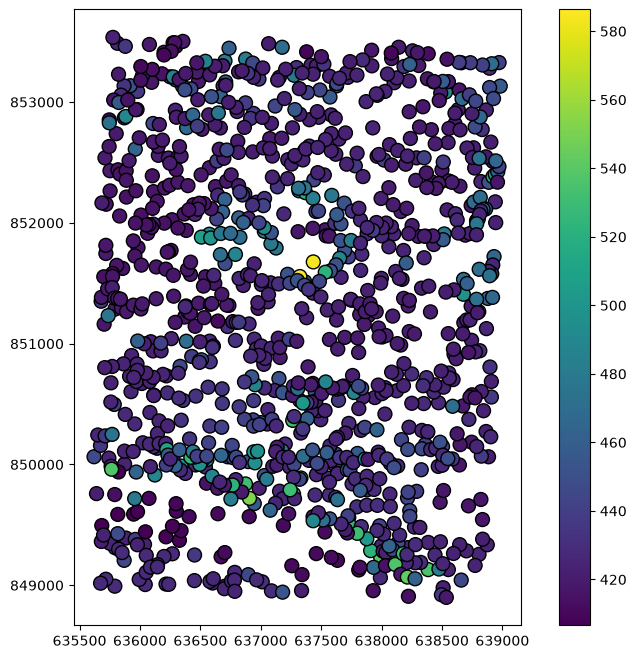

In [51]:
gdf.plot(column="Z", cmap="viridis", legend=True, markersize=100, edgecolor='black', figsize=(10, 8))

#### 2.4 Exemplo: `pumpAVisualReferenceImage.e57` com [CloudCompare](https://www.cloudcompare.org/)

<center><img src="media/imgs/e57_cloudcompare.png"> </center>


#### 2.5 Exemplo: `LiDAR-2D.csv` na unha

* **LiDAR LD14P 360º**: [ShenZhen LDROBOT Co., LTD , Sensor team](https://github.com/ldrobotSensorTeam), 360º LiDAR, de curta distânica para robôs vassoura, de 2-8Hz (default 6Hz), dist mínima de 0.1m, alcance de 6-8m dependendo da cor do objeto ser preta ou branca, suporte para ROS1, ROS2, rotinas Python rodnado no Ubuntu e Windows.
* ~~**IMU BNO055**~~
* **Raspberry Pi modelo 3B**
* **Carrinho de controle remoto**
* **Fonte de alimentação** ininterrupta (UPS) 5V - 3A, como o [UPS Module 3S](https://www.waveshare.com/wiki/UPS_Module_3S)
* **Cartão SD** com a imagem [2023-02-09-ubiquity-base-focal-raspberry-pi.img](https://learn.ubiquityrobotics.com/noetic_pi_image_downloads) instalada
* **Conexão com a internet** via cabo Ethernet (apenas para as etapas iniciais)

Montados sobre o carrinho de controle remoto:

<center><img src="media/imgs/setup-06.jpeg"> </center>

Como este LiDAR possui frequência de 6 Hz, uma rotação completa foi realizada em:

$$
6 = \frac{1}{t} \rightarrow t = 0.166s
$$

In [4]:
import pandas as pd

df = pd.read_csv(f"dados/amostras/t_x_y_z1.csv", names=["time","x","y","z"], header=None)

display(df.head())

# n = qt de nuvens de pontos
n = int((df.time.max() - df.time.min()) / 0.1666)

# Split the DataFrame into separate clouds
def select_frame(i):
    start_time = df.time.values[0]
    low_limit = (i-1)*0.1666+start_time
    high_limit = i*0.1666+start_time
    df2 = df[(df['time']>low_limit) & (df['time']<high_limit)]
    print(f"Nuvem {i-1}: {len(df2)} pontos")
    return df2

dfs = [select_frame(i) for i in range(1,n+1)]

# remove time column
for i in range(len(dfs)):
    try:
        del dfs[i]['time'] 
    except:
        pass


,time,x,y,z
0,1.731694e+09,0.000000,0.000000,0.0
1,1.731694e+09,0.000000,0.000000,0.0
2,1.731694e+09,2.715368,0.240525,0.0
3,1.731694e+09,2.823164,0.223539,0.0
4,1.731694e+09,2.848113,0.198179,0.0


Nuvem 0: 664 pontos
Nuvem 1: 664 pontos
Nuvem 2: 662 pontos
Nuvem 3: 659 pontos
Nuvem 4: 662 pontos
Nuvem 5: 662 pontos
Nuvem 6: 663 pontos
Nuvem 7: 663 pontos
Nuvem 8: 667 pontos
Nuvem 9: 665 pontos
Nuvem 10: 666 pontos
Nuvem 11: 667 pontos
Nuvem 12: 665 pontos
Nuvem 13: 666 pontos
Nuvem 14: 667 pontos
Nuvem 15: 669 pontos
Nuvem 16: 667 pontos
Nuvem 17: 667 pontos
Nuvem 18: 667 pontos
Nuvem 19: 665 pontos
Nuvem 20: 667 pontos
Nuvem 21: 667 pontos
Nuvem 22: 667 pontos
Nuvem 23: 668 pontos
Nuvem 24: 667 pontos
Nuvem 25: 666 pontos
Nuvem 26: 669 pontos
Nuvem 27: 669 pontos
Nuvem 28: 670 pontos
Nuvem 29: 670 pontos
Nuvem 30: 669 pontos
Nuvem 31: 667 pontos
Nuvem 32: 668 pontos
Nuvem 33: 667 pontos
Nuvem 34: 666 pontos
Nuvem 35: 666 pontos
Nuvem 36: 667 pontos
Nuvem 37: 665 pontos
Nuvem 38: 667 pontos
Nuvem 39: 664 pontos
Nuvem 40: 665 pontos
Nuvem 41: 666 pontos
Nuvem 42: 664 pontos
Nuvem 43: 666 pontos
Nuvem 44: 665 pontos
Nuvem 45: 667 pontos
Nuvem 46: 666 pontos
Nuvem 47: 667 pontos
Nu

<img src="media/imgs/scatter_animation1.gif">

##### **Registro final:**

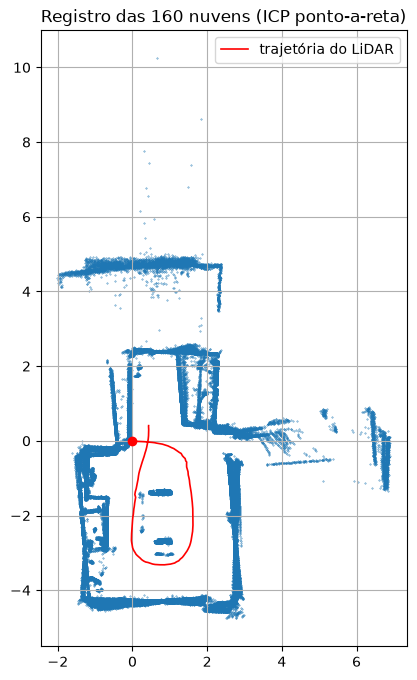

## 3. Transformações entre espaços


Cada ponto 3D vai ser projetado na imagem através da seguinte fórmula:

$$
Z_c 
\begin{bmatrix} 
u \\
v \\
1 
\end{bmatrix}= 
\underbrace{ 
        \underbrace{ 
            \begin{bmatrix} 
                f_x & 0 & c_x & 0 \\
                0 & f_y & c_y & 0 \\
                0 & 0 & 1 & 0 
            \end{bmatrix} 
        }_{Intrinsic \ parameters \ [K_{3\times 3}|0]} 
        \underbrace{ 
            \begin{bmatrix} 
                R_{3 \times 3} & t_{3\times 1} \\
                0_{1 \times 3} & 1  
            \end{bmatrix} 
        }_{Extrinsic \ parameters \ T_{4\times 4}} 
}_{P_{3\times 4}} 
\begin{bmatrix} 
X_w \\
Y_w \\
Z_w\\
1 
\end{bmatrix}
$$

<center><img src="media/imgs/modelopinhole.jpeg"> </center>

**Acumulo de transformações:** Serve para colocar nuvens de pontos inicialmente em sistemas de referência diferentes no mesmo referencial e juntá-las em uma única nuvem. A transformação $T$ é uma transformação afim, ou seja, uma combinação de uma rotação $R$ e uma translação $t$, obtidas preferencialmente por uma coleção de sensores inerciais (IMU):

$$
\begin{bmatrix}
X_{i} \\
Y_{i} \\
Z_{i} \\
1
\end{bmatrix} = 
_{i}{\left[T\right]}_{i+1}
\begin{bmatrix}
X_{i+1} \\
Y_{i+1} \\
Z_{i+1} \\
1
\end{bmatrix} 
$$

Onde:
- $_{i}{\left[T\right]}_{i+1}$ é a matriz de trasnformação da nuvem de pontos $i+1$ para a nuvem de pontos$i$.

Por exemplo, a transformação de um ponto 3D no sistema de referência da nuvem de pontos 2 para o sistema de referência da nuvem de pontos 0:

$$
_{0}{\left[T\right]}_{2} = _{0}{\left[T\right]}_{1} \cdot _{1}{\left[T\right]}_{2}
$$

E para colocar os pontos 3D na nuvem n no mesmo referencial da nuvem 0:

$$
_{0}{\left[T\right]}_{n} = _{0}{\left[T\right]}_{1} \cdot _{1}{\left[T\right]}_{2} \ \dots \  _{n-1}{\left[T\right]}_{n}
$$

## 4. Self Localization and Mapping (SLAM)

O SLAM resolve simultaneamente dois problemas acoplados:

**Localização**: estimar a posição (pose) do agente (x,y,θ) dado um mapa conhecido.

**Mapeamento**: construir o mapa M do ambiente dado que as poses são conhecidas.


<center><img src="media/imgs/slam.jpg"> </center>

### 4.1 Condições favoráveis e degeneradas

O SLAM tende a funcionar melhor com geometria variada, sobreposição, movimento suave e revisitas. Corredores longos e repetitivos, grandes planos sem feições, vidro, vegetação móvel, multidões, mudanças bruscas e poucas ligações entre setores podem degradar a solução.

Para o SLAM 100, registre sempre modelo/número de série, firmware, aplicativo, perfil de aquisição, acessórios, horário, operador e procedimento de inicialização. Valores de alcance, taxa e desempenho devem ser copiados da documentação correspondente à versão usada.

## 5. Explicar o sensor SLAM 100 e o produto

Uso Brasil: https://www.youtube.com/watch?v=zKPdSpL_JJ0

Uso no exterior: https://www.youtube.com/watch?v=YQDKb3mhSmU

Marketing: https://www.feimarobotics.net/products/3d/slam100/

Softwares: https://www.feimarobotics.net/service/softwares/

#### Intenção do cliente: 

1. Planta baixa da SE6
2. Catalogar todos os bens móveis 
3. Poder mensurar vários aspectos das instalações

#### Solução: 

O serviço que vamos fazer é levantamento interno de instalações via LiDAR. Fazer o levantamento significa, em outras palavras, fazer um catálogo de tudo que um determinado espaço tem.

- Usaremos o Scanner LiDAR para obter uma nuvem de pontos das instalações da própria SE6. 
- Processar a nuvem de pontos para classificar a parte imóvel (paredes, chão, teto, móveis, janelas, portas,...) e a parte móvel (armários, cadeiras, mesas, lâmpadas, monitores, gabinetes, teclado, mouse, ... )
- Processar a nuvem de pontos para obter uma reconstrução 3D navegável e mensurável (Exemplo: https://my.matterport.com/show/?m=UoqjwziqrZs)

#### Motivação:

- O LiDAR em conjunto com fotos, é de longe, a forma mais rápida, precisa e completa conhecida;
- Um nível de detalhe bem maior sem muitas intervenções do operador o que diminui as chances de erros grosseiros;
- O tempo de coleta, é basicamente uma caminhada ao redor da seção com o aparelho em mãos;
- O modelo 3D é navegável e mensurável, extrapolando as possibilidades do CAD;

### Ramificação deste projeto:

- Nada impede de um aluno juntar as idéias e bolar um negócio com emprego em interiores de florestas, navios, cavernas. 
- Se acoplar no drone,  emprego no exterior de florestas, fazendas, campo de obra.

## [Próximo módulo - Planejamento](02_Planejamento.ipynb): Transformar as intenções do cliente em tarefas factíveis pela equipe.